# Would I Instagram This? From Pixels to Plain English

### Iteration III — Caption-space semantics and Vision Transformer attention

---

This notebook is the full, reproducible pipeline for Iteration III of the project: four models over four
representations of the same 300 photographs, evaluated on one shared held-out test set.

Section labels `A-0` through `A-26` are stable anchors referenced from the project README.

## Section 0: What's New in Iteration III

Iterations I and II established that my photo-sharing decisions are predictable from visual features, but
the best model (CLIP + LR at 88.3%) remained opaque: no individual prediction could be explained in words.
Iteration III introduces two techniques chosen specifically to close that interpretability gap:

| Component | Status | Why It's Here |
|---|---|---|
| Handcrafted LR | Reused (Iteration I) | Low-level baseline: explicit pixel statistics |
| CNN + SVM (RBF) | Reused (Iteration II) | Best purely visual model (81.7% test acc.) |
| **Caption LR — BLIP → MiniLM** | **NEW (Iteration III)** | Tests whether plain-English descriptions predict sharing |
| **Fine-tuned ViT + Attention Rollout** | **NEW (Iteration III)** | Global self-attention + spatial attention maps |

The two reused models are controlled baselines on an identical split, so any performance difference here is
attributable to the new representations rather than to a different partition of the data.

### A-0: Imports & Setup

In [ ]:
# Install packages not pre-installed in Colab
!pip install -q transformers sentence-transformers
!pip install -q timm

In [ ]:
# ─── Core Imports ──────────────────────────────────────────────────────────────
import os
import glob
import copy
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import urllib.request
import warnings
import logging
from collections import Counter
from PIL import Image as PILImage

# Suppress verbose output
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.CRITICAL)

# ─── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc, f1_score, precision_score,
    recall_score
)

# ─── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as tv_models

# ─── HuggingFace (BLIP, ViT, MiniLM) ───────────────────────────────────────────
from transformers import (
    BlipProcessor, BlipForConditionalGeneration,
    ViTImageProcessor, ViTForImageClassification
)
from sentence_transformers import SentenceTransformer

# ─── Colab: mount Google Drive ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ─── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
PyTorch: 2.10.0+cu128


## Section 2: Data

### A-1: Data Loading & Sample Grid

Same 300 photos (150 shared, 150 personal) used in Iterations I and II. Labels self-annotated before any
feature extraction.

In [ ]:
SHARED_DIR = '/content/drive/MyDrive/photos_for_ml/shared/'
PERSONAL_DIR = '/content/drive/MyDrive/photos_for_ml/personal/'

def load_image_paths(shared_dir, personal_dir):
    """Scan directories for image files and assign binary labels.

    Parameters:
        shared_dir (str): path to directory containing shared (y=1) photos
        personal_dir (str): path to directory containing personal (y=0) photos

    Returns:
        paths (list[str]): list of all image file paths
        labels (list[int]): corresponding binary labels (1=shared, 0=personal)
    """
    extensions = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
    shared_paths, personal_paths = [], []
    for ext in extensions:
        shared_paths += glob.glob(os.path.join(shared_dir, ext))
        personal_paths += glob.glob(os.path.join(personal_dir, ext))
    paths = shared_paths + personal_paths
    labels = [1] * len(shared_paths) + [0] * len(personal_paths)
    print(f'Shared  (y=1): {len(shared_paths):>4}')
    print(f'Personal(y=0): {len(personal_paths):>4}')
    print(f'Total        : {len(paths):>4}')
    return paths, labels

image_paths, labels = load_image_paths(SHARED_DIR, PERSONAL_DIR)
labels = np.array(labels)

Shared  (y=1):  150
Personal(y=0):  150
Total        :  300


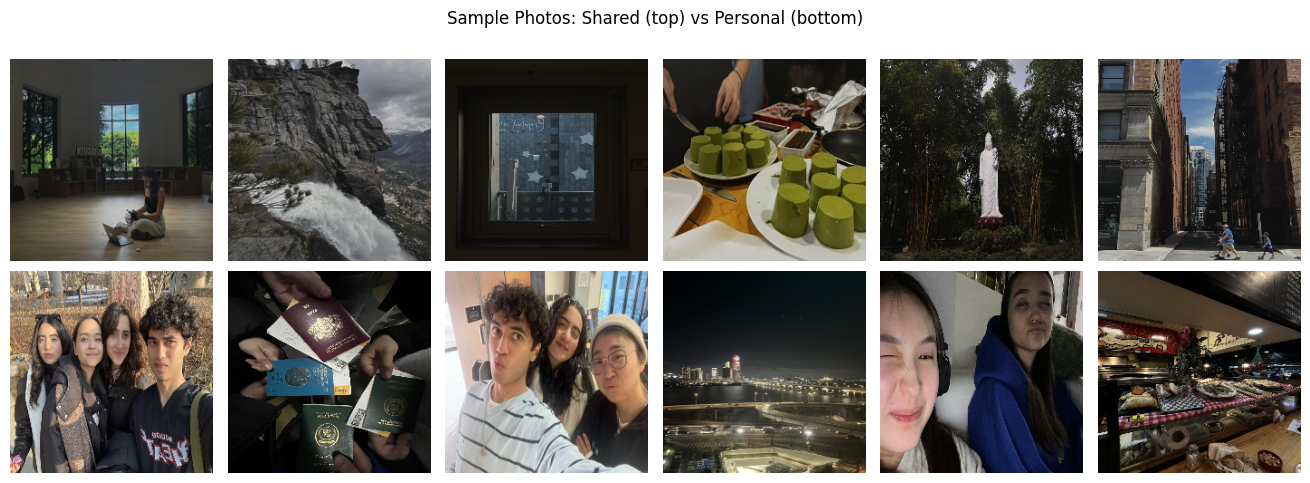

In [ ]:
# ─── Sample image grid: 6 shared + 6 personal ──────────────────────────────────
def plot_sample_grid(image_paths, labels, n_per_class=6, seed=42):
    """Display a 2x6 grid: top row shared, bottom row personal."""
    rng = np.random.RandomState(seed)
    paths_arr = np.array(image_paths)
    labels_arr = np.array(labels)

    fig, axes = plt.subplots(2, n_per_class, figsize=(n_per_class * 2.2, 5))
    for row, (cls, name) in enumerate([(1, 'Shared'), (0, 'Personal')]):
        cls_paths = paths_arr[labels_arr == cls]
        picks = rng.choice(len(cls_paths), size=n_per_class, replace=False)
        for col, idx in enumerate(picks):
            img = cv2.imread(cls_paths[idx])
            img = cv2.resize(img, (224, 224))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(name, fontsize=11, fontweight='bold')
    plt.suptitle('Sample Photos: Shared (top) vs Personal (bottom)', fontsize=12)
    plt.tight_layout()
    plt.savefig('fig_sample_grid.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_sample_grid(image_paths, labels, n_per_class=6)

## Section 3: Preprocessing & Feature Extraction

Four distinct feature representations are constructed from the same 300 raw images:

1. **Handcrafted (13d)** — reused from Iteration I
2. **CNN features (512d)** — reused from Iteration II (frozen ResNet-18 penultimate layer)
3. **BLIP captions → MiniLM embeddings (384d)** — NEW
4. **ViT raw-pixel pipeline** — NEW (tensors prepared for end-to-end fine-tuning)

### A-2: Handcrafted Features (Reused from Iteration I)

In [ ]:
# ─── Haar cascade for face detection (Viola & Jones, 2001) ────────────────────
CASCADE_PATH = '/content/haarcascade_frontalface_default.xml'
if not os.path.exists(CASCADE_PATH):
    url = ('https://raw.githubusercontent.com/opencv/opencv/master/'
           'data/haarcascades/haarcascade_frontalface_default.xml')
    urllib.request.urlretrieve(url, CASCADE_PATH)
    print('Haar cascade downloaded.')
else:
    print('Haar cascade already present.')
face_cascade = cv2.CascadeClassifier(CASCADE_PATH)

def extract_handcrafted_features(img_path, face_cascade, target_size=(256, 256)):
    """Extract 13 handcrafted visual features from a single image.

    Feature set (from Iteration I): mean_brightness, brightness_var, mean_saturation,
    saturation_var, warmth, colorfulness, mean_hue, hue_var, sharpness,
    edge_density, center_weight, face_present, face_size_ratio.

    Returns:
        dict[str, float] or None if image cannot be loaded.
    """
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None
    img_bgr = cv2.resize(img_bgr, target_size)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    H, S, V = img_hsv[:, :, 0], img_hsv[:, :, 1], img_hsv[:, :, 2]
    R = img_rgb[:, :, 0].astype(float)
    G = img_rgb[:, :, 1].astype(float)
    B = img_rgb[:, :, 2].astype(float)

    # Colour & lighting
    mean_brightness = V.mean()
    brightness_var = V.var()
    mean_saturation = S.mean()
    saturation_var = S.var()
    warmth = R.mean() - B.mean()

    # Colourfulness (Hasler & Susstrunk, 2003)
    rg = R - G
    yb = 0.5 * (R + G) - B
    colorfulness = (np.sqrt(rg.std()**2 + yb.std()**2) +
                    0.3 * np.sqrt(rg.mean()**2 + yb.mean()**2))

    mean_hue = H.mean()
    hue_var = H.var()

    # Sharpness: Laplacian variance
    sharpness = cv2.Laplacian(img_gray, cv2.CV_64F).var()

    # Edge density: Canny
    edges = cv2.Canny(img_bgr, threshold1=50, threshold2=150)
    edge_density = edges.astype(bool).mean()

    # Composition: centre brightness ratio
    h, w = V.shape
    mh, mw = h // 4, w // 4
    center_crop = V[mh:h - mh, mw:w - mw]
    center_weight = center_crop.mean() / (mean_brightness + 1e-6)

    # Face detection
    faces = face_cascade.detectMultiScale(
        img_gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    face_present = 1 if len(faces) > 0 else 0
    face_size_ratio = (
        max(wf * hf for (_, _, wf, hf) in faces) / (h * w) if face_present else 0.0
    )

    return dict(
        mean_brightness=mean_brightness, brightness_var=brightness_var,
        mean_saturation=mean_saturation, saturation_var=saturation_var,
        warmth=warmth, colorfulness=colorfulness,
        mean_hue=mean_hue, hue_var=hue_var,
        sharpness=sharpness, edge_density=edge_density,
        center_weight=center_weight, face_present=face_present,
        face_size_ratio=face_size_ratio,
    )

# Build DataFrame
print('Extracting handcrafted features...')
records = []
for path, label in zip(image_paths, labels):
    feats = extract_handcrafted_features(path, face_cascade)
    if feats is not None:
        feats['label'] = int(label)
        feats['filename'] = os.path.basename(path)
        records.append(feats)

df = pd.DataFrame(records)
feature_cols = [c for c in df.columns if c not in ('label', 'filename')]
X_hand = df[feature_cols].values.astype(np.float64)
y = df['label'].values
print(f'Handcrafted feature matrix: {X_hand.shape}')

Haar cascade already present.
Extracting handcrafted features...
Handcrafted feature matrix: (300, 13)


### A-3: CNN Features — Frozen ResNet-18 (Reused from Iteration II)

In [ ]:
def build_cnn_feature_extractor(device):
    """Load pretrained ResNet-18 with FC head removed.

    Returns:
        model: ResNet-18 in eval mode on device (outputs 512-d vectors)
        preprocess: ImageNet-normalised 224x224 centre-crop pipeline
    """
    weights = tv_models.ResNet18_Weights.IMAGENET1K_V1
    model = tv_models.resnet18(weights=weights)
    model.fc = nn.Identity()
    model = model.to(device)
    model.eval()
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    return model, preprocess

def extract_cnn_features(image_paths, model, preprocess, device):
    """Pass every image through the frozen CNN and collect 512-d features."""
    features_list = []
    failed = 0
    for i, path in enumerate(image_paths):
        try:
            img = PILImage.open(path).convert('RGB')
            img_tensor = preprocess(img).unsqueeze(0).to(device)
            with torch.no_grad():
                feat = model(img_tensor)
            features_list.append(feat.cpu().numpy().flatten())
        except Exception:
            features_list.append(np.zeros(512))
            failed += 1
        if (i + 1) % 100 == 0:
            print(f'  {i+1}/{len(image_paths)} processed')
    return np.array(features_list), failed

print('Loading ResNet-18...')
cnn_model, cnn_preprocess = build_cnn_feature_extractor(DEVICE)
print('Extracting CNN features...')
X_cnn, cnn_failed = extract_cnn_features(image_paths, cnn_model, cnn_preprocess, DEVICE)
print(f'CNN feature matrix: {X_cnn.shape} (failed: {cnn_failed})')

Loading ResNet-18...
Extracting CNN features...
  100/300 processed
  200/300 processed
  300/300 processed
CNN feature matrix: (300, 512) (failed: 0)


### A-4: BLIP Caption Generation (NEW)

BLIP (Bootstrapping Language-Image Pre-training, Li et al. 2022) uses a frozen ViT-B/16 visual encoder to produce patch embeddings that condition an autoregressive language decoder. The decoder generates captions one token at a time, cross-attending to all visual patch embeddings at every step:

$$P(w_1, \ldots, w_T \mid \text{image}) = \prod_{t=1}^{T} P(w_t \mid w_{<t}, \{v_1, \ldots, v_N\})$$

We use `Salesforce/blip-image-captioning-base` via HuggingFace, deterministic beam search, one caption per image.

In [ ]:
# ─── Load BLIP captioning model ────────────────────────────────────────────────
print('Loading BLIP...')
blip_processor = BlipProcessor.from_pretrained('Salesforce/blip-image-captioning-base')
blip_model = BlipForConditionalGeneration.from_pretrained(
    'Salesforce/blip-image-captioning-base'
).to(DEVICE)
blip_model.eval()

def generate_blip_caption(img_path, processor, model, device, max_length=50):
    """Generate a single deterministic caption for one image using beam search."""
    img = PILImage.open(img_path).convert('RGB')
    inputs = processor(img, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model.generate(**inputs, max_length=max_length, num_beams=3,
                             repetition_penalty=1.8,no_repeat_ngram_size=2
                             )
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption

# Generate captions for all 300 images
print('Generating BLIP captions (this takes a few minutes)...')
captions = []
for i, path in enumerate(image_paths):
    try:
        cap = generate_blip_caption(path, blip_processor, blip_model, DEVICE)
    except Exception as e:
        cap = ''
        print(f'  failed on {os.path.basename(path)}: {e}')
    captions.append(cap)
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(image_paths)} captioned')

df['caption'] = captions
print(f'\nGenerated {len(captions)} captions')
print('\nSample captions:')
for cls, name in [(1, 'Shared'), (0, 'Personal')]:
    idxs = np.where(labels == cls)[0][:4]
    print(f'\n--- {name} ---')
    for idx in idxs:
        print(f'  "{captions[idx]}"')

Loading BLIP...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Generating BLIP captions (this takes a few minutes)...
  50/300 captioned
  100/300 captioned
  150/300 captioned
  200/300 captioned
  250/300 captioned
  300/300 captioned

Generated 300 captions

Sample captions:

--- Shared ---
  "a river with trees and mountains in the background"
  "a man standing in the middle of a grassy field"
  "the interior of a restaurant with large windows"
  "a large waterfall is coming out of the side of a mountain"

--- Personal ---
  "a person walking through a store filled with stuffed animals"
  "a person holding a hot dog in their hand"
  "a woman standing next to a man in a santa suit"
  "a man standing next to a santa clause"


In [ ]:
# Save all captions to CSV for inspection
caption_df = pd.DataFrame({
    'filename': [os.path.basename(p) for p in image_paths],
    'true_label': labels,
    'caption': captions
})
caption_df.to_csv('all_captions.csv', index=False)
print(f"Saved {len(caption_df)} captions to all_captions.csv")

Saved 300 captions to all_captions.csv


In [ ]:
from google.colab import files
files.download('all_captions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Show a random sample of 20 shared and 20 personal captions
sample_shared = caption_df[caption_df['true_label'] == 1].sample(20, random_state=SEED)
sample_personal = caption_df[caption_df['true_label'] == 0].sample(20, random_state=SEED)
print("Sample Shared Captions:")
display(sample_shared[['filename', 'caption']])
print("\nSample Personal Captions:")
display(sample_personal[['filename', 'caption']])

Sample Shared Captions:


,filename,caption
73,0EFD2AA1-823B-4C37-954F-6890922E5BF1_4_5005_c....,a woman sitting on the floor in an empty room
18,6773BB17-7DD1-44B9-B580-32AD887511DA_4_5005_c....,a waterfall on the side of a mountain
118,C986D05E-B3F0-4C4D-AED1-9FA8421EA2D3_1_105_c.jpeg,a cat is sitting in the window of a building
78,5B68D045-9A36-4175-84A6-9F855B9F084F_4_5005_c....,two plates of green puddings on a wooden table
76,60835218-0D35-4E2E-9ED1-9D14A6E40759_1_105_c.jpeg,a large white statue in the middle of a forest
31,BE68111F-1634-4554-A85D-74626B53A93C_1_105_c.jpeg,a couple of people walking down a street next ...
64,DD91574C-2CB7-49A1-8F66-79EED40CD8F6_4_5005_c....,a blue rooster statue in front of a building
141,77ED2D53-5AB7-47A1-954C-EB4DC13339A8_1_105_c.jpeg,a restaurant with tables and chairs in front o...
68,C0B7FFC6-399D-46EE-98DA-CBCE85B6D18D_4_5005_c....,an old building with a tall tower in the backg...
82,5834D648-141D-4C5C-90CA-0B31478CE494_4_5005_c....,a woman sitting on the ground in front of an o...



Sample Personal Captions:


,filename,caption
223,405410B6-EC7C-41DE-AC71-95AEC37AD3CC_4_5005_c....,a woman sitting at a desk in front of a computer
168,2AC422AF-BA72-4339-B4CF-63A1ED07AEF9_4_5005_c....,a man sitting on top of a woman ' s lap
268,53FC76A0-7AA9-40C4-BCA8-721E15EB0ED2_1_105_c.jpeg,a woman sitting on the floor with her hands ov...
228,106CE407-E997-4572-82AA-F164B350F132_4_5005_c....,a man sitting on a bench holding a bag of food
226,8B77A740-43E3-4835-BB5A-4213581BAEB3_4_5005_c....,a man taking a picture of a woman in a mirror
181,29D5B7AB-1556-4ECC-AD33-5C2C9F1E8BCE_1_105_c.jpeg,a woman wearing glasses and a hat
214,88408556-195F-4FAB-B994-D9ACF1584791_1_105_c.jpeg,two men standing in front of a table with a sign
291,F8751556-FE16-4BE7-99BF-316D5A3EF9B2_1_105_c.jpeg,two people standing in front of a wine rack
218,D707188A-5E8B-480E-81CF-BF0514D5019B_1_105_c.jpeg,a building with graffiti on the side of it
232,5DAA6205-8655-461A-882C-EDDAEA1E3BAC_1_105_c.jpeg,a group of people standing in an elevator


### A-5: Sentence Embedding — MiniLM (NEW)

`all-MiniLM-L6-v2` (Reimers & Gurevych, 2019) is a 6-layer transformer trained contrastively on 1B sentence pairs. For caption $c$:

$$\mathbf{h} = \text{MeanPool}(\text{TransformerEncoder}(c)) \in \mathbb{R}^{384}$$

Output shape: (300, 384) — the feature matrix for Caption LR.

In [ ]:
print('Loading MiniLM...')
minilm_model = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)

print('Encoding captions...')
X_caption = minilm_model.encode(captions, show_progress_bar=True,
                                convert_to_numpy=True)
print(f'Caption embedding matrix: {X_caption.shape}')

Loading MiniLM...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding captions...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Caption embedding matrix: (300, 384)


### A-6: ViT Data Preparation (NEW)

Raw pixels at 224x224 with ImageNet normalisation. Training augmentation (train split only): RandomResizedCrop, RandomHorizontalFlip, ColorJitter. Validation/test use clean transforms.

In [ ]:
# ViT uses the same ImageNet mean/std as the frozen ResNet pipeline
vit_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

vit_eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class PhotoDataset(Dataset):
    """Loads images from file paths and applies a given torchvision transform."""

    def __init__(self, paths, labels, transform):
        self.paths = list(paths)
        self.labels = np.asarray(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = PILImage.open(self.paths[idx]).convert('RGB')
        img = self.transform(img)
        label = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return img, label

print('ViT data pipeline ready.')

ViT data pipeline ready.


### A-7: Exploratory Data Analysis

#### 3.7.1 Cohen's d (handcrafted features)

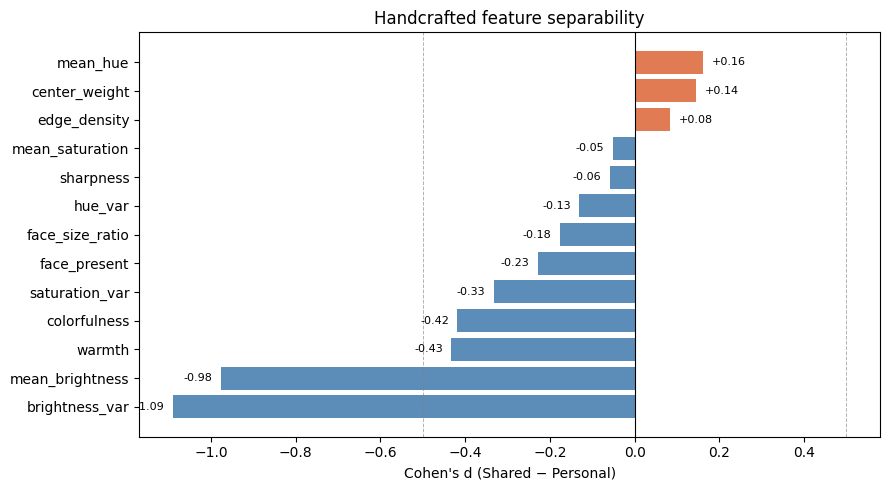


Top |d| features:
brightness_var    -1.090198
mean_brightness   -0.976115
warmth            -0.432675
colorfulness      -0.418513
saturation_var    -0.332518
dtype: float64


In [ ]:
def cohens_d(group0, group1):
    """Pooled-variance Cohen's d between two 1-D arrays."""
    n0, n1 = len(group0), len(group1)
    var0, var1 = group0.var(ddof=1), group1.var(ddof=1)
    pooled = np.sqrt(((n0 - 1) * var0 + (n1 - 1) * var1) / (n0 + n1 - 2))
    return (group1.mean() - group0.mean()) / (pooled + 1e-9)

g0 = df[df['label'] == 0]
g1 = df[df['label'] == 1]
d_vals = {f: cohens_d(g0[f], g1[f]) for f in feature_cols}
d_series = pd.Series(d_vals).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E07B54' if d > 0 else '#5B8DB8' for d in d_series.values]
ax.barh(d_series.index, d_series.values, color=colors)
ax.axvline(0, color='k', lw=0.8)
ax.axvline(0.5, color='gray', ls='--', lw=0.7, alpha=0.6)
ax.axvline(-0.5, color='gray', ls='--', lw=0.7, alpha=0.6)
ax.set_xlabel("Cohen's d (Shared − Personal)")
ax.set_title('Handcrafted feature separability')
for i, (_, d) in enumerate(zip(d_series.index, d_series.values)):
    x_text = d + 0.02 if d > 0 else d - 0.02
    ha = 'left' if d > 0 else 'right'
    ax.text(x_text, i, f'{d:+.2f}', va='center', ha=ha, fontsize=8)
plt.tight_layout()
plt.savefig('fig_cohens_d.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop |d| features:')
print(d_series.reindex(d_series.abs().sort_values(ascending=False).index).head(5))

#### 3.7.2 Caption Word Frequency

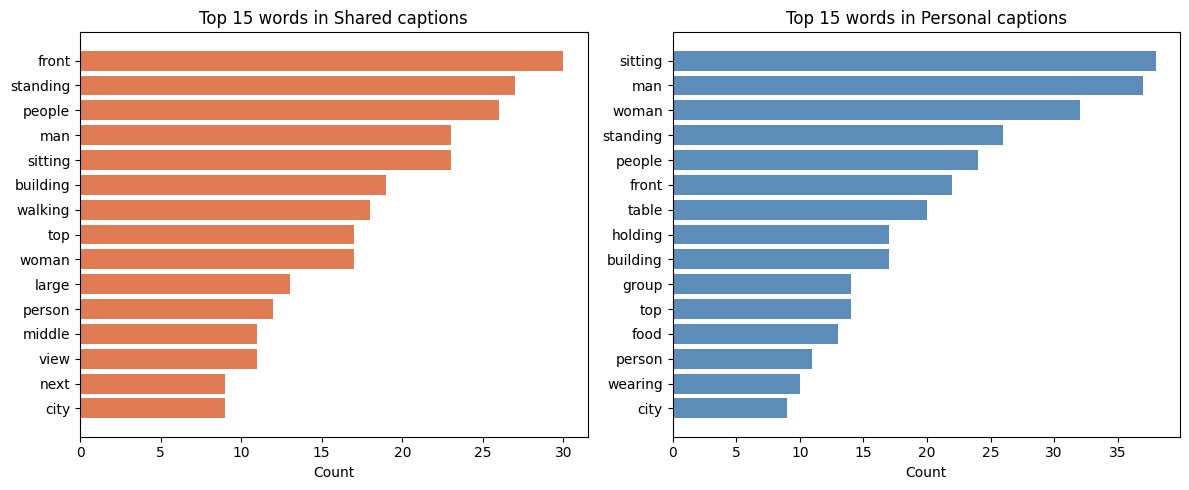


Shared-only (top 15): ['large', 'middle', 'next', 'view', 'walking']
Personal-only (top 15): ['food', 'group', 'holding', 'table', 'wearing']
Overlap: ['building', 'city', 'front', 'man', 'people', 'person', 'sitting', 'standing', 'top', 'woman']


In [ ]:
# Simple English stopword list (no NLTK download required)
STOPWORDS = set("""
a an the and or but if then of to in on at by for with from as is are was were be been being
it its this that these those there here which who whom whose what where when why how
not no do does did have has had i you he she we they them his her their our your my me us
will would can could should may might up down out over into about very just also all
any some each one two s t
""".split())

def word_counts(caption_list, stopwords=STOPWORDS):
    """Tokenise captions, lowercase, strip stopwords, return Counter."""
    counter = Counter()
    for cap in caption_list:
        tokens = [w.lower().strip('.,!?;:"\'') for w in cap.split()]
        tokens = [w for w in tokens if w and w not in stopwords and len(w) > 2]
        counter.update(tokens)
    return counter

shared_caps = [captions[i] for i in range(len(captions)) if labels[i] == 1]
personal_caps = [captions[i] for i in range(len(captions)) if labels[i] == 0]

shared_counts = word_counts(shared_caps)
personal_counts = word_counts(personal_caps)

top_shared = shared_counts.most_common(15)
top_personal = personal_counts.most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

words_s, counts_s = zip(*top_shared)
axes[0].barh(list(reversed(words_s)), list(reversed(counts_s)), color='#E07B54')
axes[0].set_title('Top 15 words in Shared captions')
axes[0].set_xlabel('Count')

words_p, counts_p = zip(*top_personal)
axes[1].barh(list(reversed(words_p)), list(reversed(counts_p)), color='#5B8DB8')
axes[1].set_title('Top 15 words in Personal captions')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('fig_word_freq.png', dpi=150, bbox_inches='tight')
plt.show()

# Print exclusive words
shared_only = set(dict(top_shared).keys()) - set(dict(top_personal).keys())
personal_only = set(dict(top_personal).keys()) - set(dict(top_shared).keys())
overlap = set(dict(top_shared).keys()) & set(dict(top_personal).keys())
print(f'\nShared-only (top 15): {sorted(shared_only)}')
print(f'Personal-only (top 15): {sorted(personal_only)}')
print(f'Overlap: {sorted(overlap)}')

#### 3.7.3 Embedding space: handcrafted PCA vs. caption t-SNE

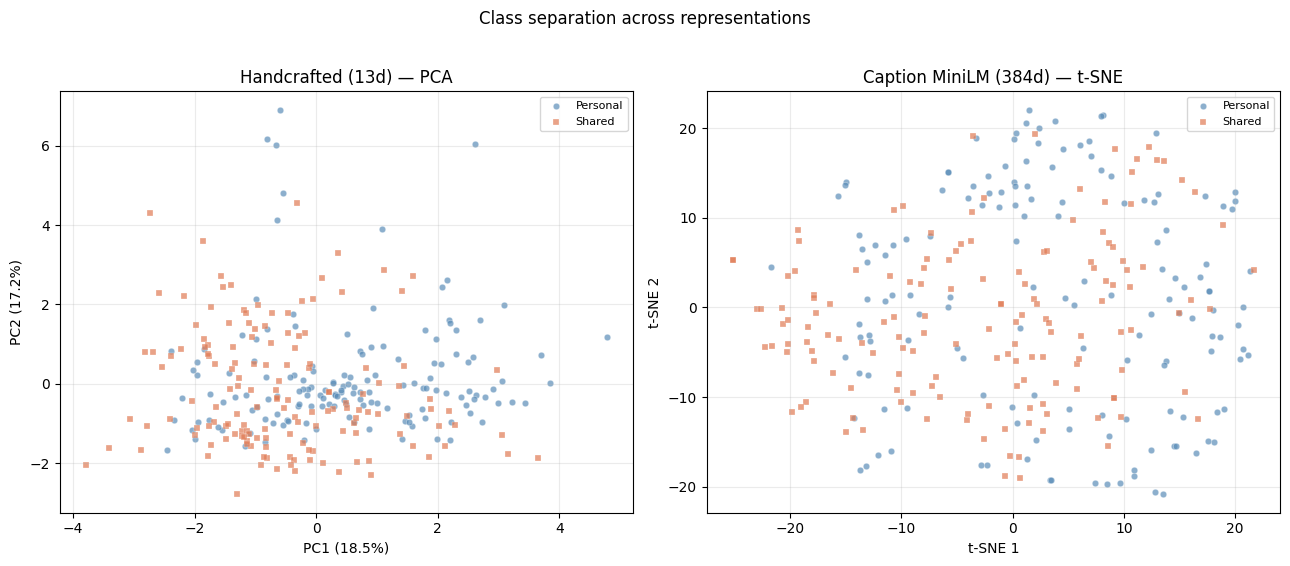

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel (a): PCA on scaled handcrafted features
pca_hand = PCA(n_components=2, random_state=SEED)
X_hand_2d = pca_hand.fit_transform(StandardScaler().fit_transform(X_hand))
ve = pca_hand.explained_variance_ratio_
for cls, name, color, marker in [(0, 'Personal', '#5B8DB8', 'o'),
                                  (1, 'Shared', '#E07B54', 's')]:
    m = y == cls
    axes[0].scatter(X_hand_2d[m, 0], X_hand_2d[m, 1], c=color, marker=marker,
                    s=22, alpha=0.7, edgecolors='white', linewidths=0.3, label=name)
axes[0].set_xlabel(f'PC1 ({ve[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({ve[1]*100:.1f}%)')
axes[0].set_title('Handcrafted (13d) — PCA')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.25)

# Panel (b): t-SNE on scaled caption embeddings
tsne_cap = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_cap_2d = tsne_cap.fit_transform(StandardScaler().fit_transform(X_caption))
for cls, name, color, marker in [(0, 'Personal', '#5B8DB8', 'o'),
                                  (1, 'Shared', '#E07B54', 's')]:
    m = y == cls
    axes[1].scatter(X_cap_2d[m, 0], X_cap_2d[m, 1], c=color, marker=marker,
                    s=22, alpha=0.7, edgecolors='white', linewidths=0.3, label=name)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('Caption MiniLM (384d) — t-SNE')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.25)

plt.suptitle('Class separation across representations', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_embedding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.7.4 Class-conditional statistics (reference from Iteration I)

In [ ]:
class_means = df.groupby('label')[feature_cols].mean().round(2)
class_means.index = ['Personal (y=0)', 'Shared (y=1)']
key = ['mean_brightness', 'brightness_var', 'face_present']
print('Class-conditional means (key features):')
print(class_means[key].T)

Class-conditional means (key features):
                 Personal (y=0)  Shared (y=1)
mean_brightness      124.820000     96.040001
brightness_var      3910.709961   2615.489990
face_present           0.150000      0.080000


## Section 4: Analysis Design & Train/Test Split

### A-8: Split & Scaling

Identical split to Iterations I and II: `train_test_split(test_size=0.2, random_state=42, stratify=y)`.
240 training / 60 test, 50/50 in each. The test set is held out entirely until Section 7.

In [ ]:
# Stratified 80/20 split using a single index array
indices = np.arange(len(image_paths))
idx_train, idx_test = train_test_split(
    indices, test_size=0.2, random_state=SEED, stratify=y
)

# Split every feature representation with the same indices
X_hand_train, X_hand_test = X_hand[idx_train], X_hand[idx_test]
X_cnn_train, X_cnn_test = X_cnn[idx_train], X_cnn[idx_test]
X_cap_train, X_cap_test = X_caption[idx_train], X_caption[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

# Path lists for image-based models
train_paths = [image_paths[i] for i in idx_train]
test_paths = [image_paths[i] for i in idx_test]

# Scale each feature set (fit on train only)
scaler_hand = StandardScaler().fit(X_hand_train)
X_hand_train_s = scaler_hand.transform(X_hand_train)
X_hand_test_s = scaler_hand.transform(X_hand_test)

scaler_cnn = StandardScaler().fit(X_cnn_train)
X_cnn_train_s = scaler_cnn.transform(X_cnn_train)
X_cnn_test_s = scaler_cnn.transform(X_cnn_test)

scaler_cap = StandardScaler().fit(X_cap_train)
X_cap_train_s = scaler_cap.transform(X_cap_train)
X_cap_test_s = scaler_cap.transform(X_cap_test)

print('=' * 60)
print('DATA SPLIT')
print('=' * 60)
print(f'Train: {len(y_train):3d} (class 0: {np.sum(y_train==0)}, class 1: {np.sum(y_train==1)})')
print(f'Test : {len(y_test):3d} (class 0: {np.sum(y_test==0)}, class 1: {np.sum(y_test==1)})')

DATA SPLIT
Train: 240 (class 0: 120, class 1: 120)
Test :  60 (class 0: 30, class 1: 30)


## Section 5: Model Construction

Four models, each tied to a specific sub-question:

1. **Handcrafted LR** — interpretable pixel-stats floor (reused from Iteration I)
2. **CNN + SVM (RBF)** — best purely visual model (reused from Iteration II)
3. **Caption LR** — BLIP → MiniLM → LR (tests H1: are descriptions enough?)
4. **Fine-tuned ViT + attention rollout** — tests H2: does global self-attention capture composition?

### A-9: LR on Handcrafted (reused, Iteration I)

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b), \quad \sigma(z) = \frac{1}{1+e^{-z}}$$

Objective: L2-regularised binary cross-entropy. Config: `penalty='l2'`, `C=1.0`, `solver='lbfgs'`.

In [ ]:
lr_hand = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=SEED
)

### A-10: SVM RBF on CNN (reused, Iteration II)

Soft-margin dual with RBF kernel:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$$

Decision: $f(\mathbf{x}) = \text{sign}\big(\sum_{i\in SV} \alpha_i y_i K(\mathbf{x}_i, \mathbf{x}) + b\big)$. Grid-searched over $C, \gamma$ in Iteration II; kept consistent here.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

svm_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'gamma': [0.001, 0.01, 0.1, 1.0, 'scale'],
}
svm_base = SVC(kernel='rbf', probability=True, random_state=SEED)
svm_search = GridSearchCV(
    svm_base, svm_param_grid, cv=cv, scoring='accuracy', n_jobs=-1
)

### A-11: Caption LR (NEW)

LR on MiniLM caption embeddings. In the high-dimensional / low-sample regime (384d, 240 train), strong regularisation is expected. Grid search over $C \in \{10^{-3}, 10^{-2}, 10^{-1}, 1, 10\}$.

In [ ]:
cap_lr_search = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=SEED,
                       penalty='l2', solver='lbfgs'),
    {'C': [0.001, 0.01, 0.1, 1.0, 10.0]},
    cv=cv, scoring='accuracy', n_jobs=-1,
)

### A-12: Fine-tuned ViT Setup (NEW)

Model: `google/vit-base-patch16-224`, pretrained on ImageNet-21k. Strategy: freeze everything except the last 4 transformer blocks and the classification head. Optimiser: AdamW, `lr=2e-5`, `weight_decay=1e-4`. Early stopping on val loss, patience 5.

In [ ]:
def build_finetuned_vit(num_labels=2, device=DEVICE, n_unfrozen_blocks=4):
    """Load pretrained ViT-Base/16, replace classifier head, freeze all
    encoder blocks except the last `n_unfrozen_blocks`.
    """
    model = ViTForImageClassification.from_pretrained(
        'google/vit-base-patch16-224',
        num_labels=num_labels,
        ignore_mismatched_sizes=True,
        attn_implementation="eager"
    )

    model.config.output_attentions = True

    # Freeze embeddings + all encoder layers initially
    for p in model.parameters():
        p.requires_grad = False

    # Unfreeze last n_unfrozen_blocks transformer layers
    encoder_layers = model.vit.encoder.layer
    total_layers = len(encoder_layers)
    for layer in encoder_layers[total_layers - n_unfrozen_blocks:]:
        for p in layer.parameters():
            p.requires_grad = True

    # Unfreeze final layernorm + classification head
    for p in model.vit.layernorm.parameters():
        p.requires_grad = True
    for p in model.classifier.parameters():
        p.requires_grad = True

    model = model.to(device)

    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total parameters    : {total:,}')
    print(f'Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)')
    print(f'Frozen parameters   : {total - trainable:,}')
    return model

print('Building ViT...')
vit_model = build_finetuned_vit(num_labels=2, device=DEVICE)

Building ViT...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Total parameters    : 85,800,194
Trainable parameters: 28,354,562 (33.0%)
Frozen parameters   : 57,445,632


## Section 6: Training & Cross-Validation

### A-13: LR on Handcrafted — CV

In [ ]:
lr_hand.fit(X_hand_train_s, y_train)
cv_lr_hand = cross_val_score(lr_hand, X_hand_train_s, y_train,
                             cv=cv, scoring='accuracy')
print(f'LR (Handcrafted): CV = {cv_lr_hand.mean():.3f} ± {cv_lr_hand.std():.3f}')
print(f'  Fold scores: {np.round(cv_lr_hand, 3)}')

LR (Handcrafted): CV = 0.775 ± 0.031
  Fold scores: [0.75  0.75  0.771 0.833 0.771]


### A-14: SVM RBF on CNN — Grid Search

In [ ]:
print('SVM hyperparameter search (25 combos x 5 folds)...')
svm_search.fit(X_cnn_train_s, y_train)
best_svm = svm_search.best_estimator_
print(f'SVM (RBF, CNN): CV = {svm_search.best_score_:.3f}')
print(f'  Best C = {svm_search.best_params_["C"]}, '
      f'best gamma = {svm_search.best_params_["gamma"]}')

SVM hyperparameter search (25 combos x 5 folds)...
SVM (RBF, CNN): CV = 0.817
  Best C = 10.0, best gamma = scale


### A-15: Caption LR — Grid Search & CV

In [ ]:
print('Caption LR hyperparameter search...')
cap_lr_search.fit(X_cap_train_s, y_train)
best_cap_lr = cap_lr_search.best_estimator_
best_C_cap = cap_lr_search.best_params_['C']
best_cv_cap = cap_lr_search.best_score_

# Fold-level scores at best C
best_idx = cap_lr_search.best_index_
cap_fold_scores = [cap_lr_search.cv_results_[f'split{i}_test_score'][best_idx]
                   for i in range(5)]

print(f'Caption LR: CV = {best_cv_cap:.3f} ± {np.std(cap_fold_scores):.3f}')
print(f'  Best C = {best_C_cap}')
print(f'  Fold scores: {np.round(cap_fold_scores, 3)}')

# Full grid results for reference
cap_cv_df = pd.DataFrame({
    'C': [p['C'] for p in cap_lr_search.cv_results_['params']],
    'CV Accuracy': cap_lr_search.cv_results_['mean_test_score'].round(3),
    'CV Std': cap_lr_search.cv_results_['std_test_score'].round(3),
})
print('\nCaption LR grid:')
print(cap_cv_df.to_string(index=False))

Caption LR hyperparameter search...
Caption LR: CV = 0.775 ± 0.061
  Best C = 0.001
  Fold scores: [0.75  0.792 0.875 0.688 0.771]

Caption LR grid:
     C  CV Accuracy  CV Std
 0.001        0.775   0.061
 0.010        0.775   0.033
 0.100        0.733   0.053
 1.000        0.717   0.073
10.000        0.704   0.057


### A-16: ViT Fine-tuning Loop + Early Stopping

In [ ]:
# ViT uses a single 80/20 split of the training set (same as the Iteration II fine-tuning approach)
train_paths_arr = np.array(train_paths)

ft_train_idx, ft_val_idx = train_test_split(
    np.arange(len(y_train)), test_size=0.2,
    random_state=SEED, stratify=y_train
)

vit_train_ds = PhotoDataset(train_paths_arr[ft_train_idx],
                            y_train[ft_train_idx], vit_train_transform)
vit_val_ds = PhotoDataset(train_paths_arr[ft_val_idx],
                          y_train[ft_val_idx], vit_eval_transform)

vit_train_loader = DataLoader(vit_train_ds, batch_size=16, shuffle=True,
                              num_workers=2, pin_memory=True)
vit_val_loader = DataLoader(vit_val_ds, batch_size=16, shuffle=False,
                            num_workers=2, pin_memory=True)

print(f'ViT train: {len(vit_train_ds)}, val: {len(vit_val_ds)}')

def train_vit(model, train_loader, val_loader, device,
              epochs=25, lr=2e-5, weight_decay=1e-4, patience=5):
    """Train ViT with AdamW + early stopping on validation loss.

    AdamW (Loshchilov & Hutter, 2019) decouples weight decay from the adaptive
    gradient step, which is the preferred regulariser for transformer fine-tuning.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )

    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None
    best_epoch = 0
    patience_counter = 0

    for epoch in range(epochs):
        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out = model(pixel_values=imgs).logits
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(dim=1) == lbls).sum().item()
            total += imgs.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        # ── Validate ───────────────────────────────────────────────────────
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(pixel_values=imgs).logits
                loss = criterion(out, lbls)
                running_loss += loss.item() * imgs.size(0)
                correct += (out.argmax(dim=1) == lbls).sum().item()
                total += imgs.size(0)
        val_loss = running_loss / total
        val_acc = correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # ── Early stopping ─────────────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            patience_counter = 0
        else:
            patience_counter += 1

        print(f'  Epoch {epoch+1:3d}: '
              f'train_loss={train_loss:.4f} val_loss={val_loss:.4f} '
              f'train_acc={train_acc:.3f} val_acc={val_acc:.3f}')

        if patience_counter >= patience:
            print(f'  Early stopping at epoch {epoch+1} (best was epoch {best_epoch})')
            break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_epoch

print('\nTraining ViT...')
vit_model, vit_history, vit_best_epoch = train_vit(
    vit_model, vit_train_loader, vit_val_loader, DEVICE,
    epochs=25, lr=2e-5, weight_decay=1e-4, patience=5
)
print(f'\nBest epoch: {vit_best_epoch}')
print(f'Best val accuracy: {max(vit_history["val_acc"]):.3f}')

ViT train: 192, val: 48

Training ViT...
  Epoch   1: train_loss=0.7455 val_loss=0.6133 train_acc=0.589 val_acc=0.542
  Epoch   2: train_loss=0.5788 val_loss=0.5481 train_acc=0.714 val_acc=0.729
  Epoch   3: train_loss=0.4895 val_loss=0.4991 train_acc=0.818 val_acc=0.833
  Epoch   4: train_loss=0.4029 val_loss=0.4725 train_acc=0.875 val_acc=0.833
  Epoch   5: train_loss=0.3735 val_loss=0.4542 train_acc=0.854 val_acc=0.833
  Epoch   6: train_loss=0.3207 val_loss=0.4413 train_acc=0.885 val_acc=0.833
  Epoch   7: train_loss=0.2664 val_loss=0.4345 train_acc=0.927 val_acc=0.833
  Epoch   8: train_loss=0.2226 val_loss=0.4304 train_acc=0.969 val_acc=0.833
  Epoch   9: train_loss=0.1949 val_loss=0.4168 train_acc=0.969 val_acc=0.833
  Epoch  10: train_loss=0.1712 val_loss=0.4135 train_acc=0.974 val_acc=0.833
  Epoch  11: train_loss=0.1508 val_loss=0.4160 train_acc=0.969 val_acc=0.833
  Epoch  12: train_loss=0.1316 val_loss=0.4183 train_acc=0.984 val_acc=0.833
  Epoch  13: train_loss=0.1209 val_

### A-17: ViT Training Curves

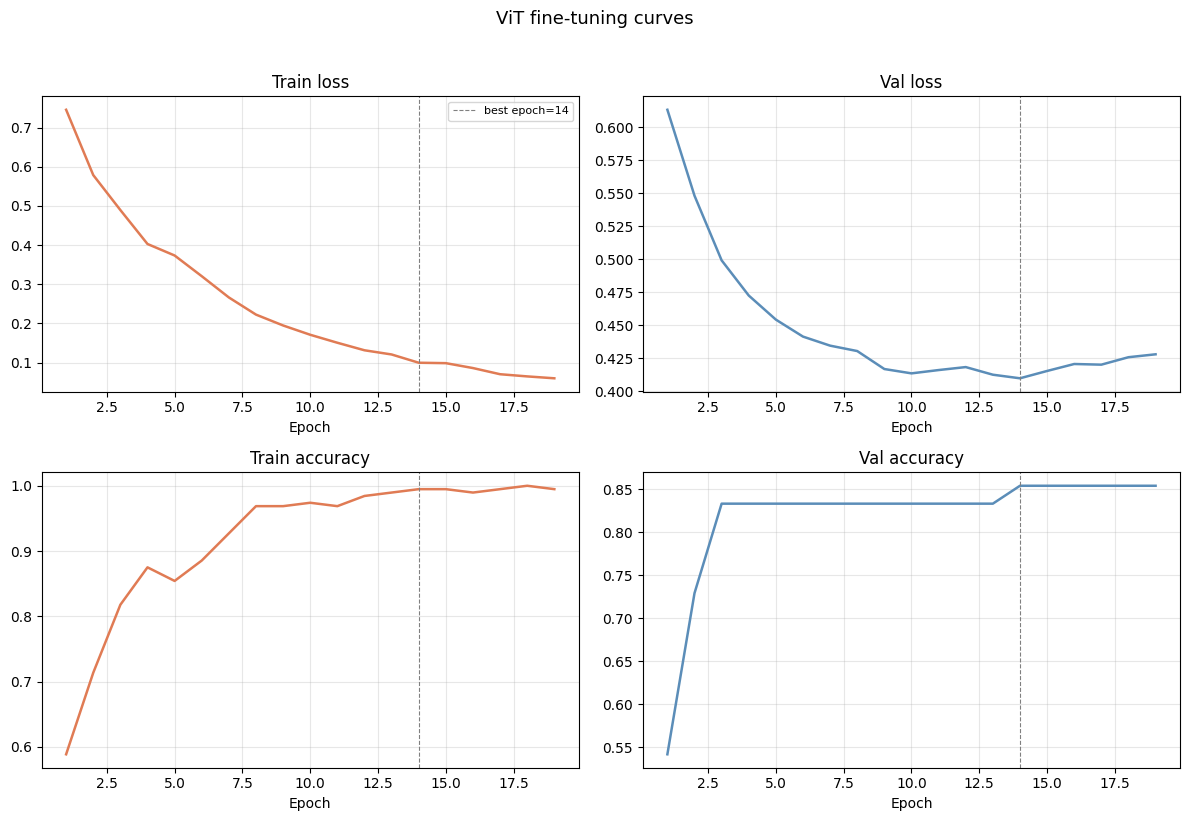

Train acc at best epoch: 0.995
Val acc at best epoch  : 0.854
Train/val gap: +0.141


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
epochs_range = range(1, len(vit_history['train_loss']) + 1)

axes[0, 0].plot(epochs_range, vit_history['train_loss'], color='#E07B54', lw=1.8)
axes[0, 0].axvline(vit_best_epoch, color='gray', ls='--', lw=0.8,
                   label=f'best epoch={vit_best_epoch}')
axes[0, 0].set_title('Train loss'); axes[0, 0].set_xlabel('Epoch')
axes[0, 0].grid(True, alpha=0.3); axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(epochs_range, vit_history['val_loss'], color='#5B8DB8', lw=1.8)
axes[0, 1].axvline(vit_best_epoch, color='gray', ls='--', lw=0.8)
axes[0, 1].set_title('Val loss'); axes[0, 1].set_xlabel('Epoch')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs_range, vit_history['train_acc'], color='#E07B54', lw=1.8)
axes[1, 0].axvline(vit_best_epoch, color='gray', ls='--', lw=0.8)
axes[1, 0].set_title('Train accuracy'); axes[1, 0].set_xlabel('Epoch')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs_range, vit_history['val_acc'], color='#5B8DB8', lw=1.8)
axes[1, 1].axvline(vit_best_epoch, color='gray', ls='--', lw=0.8)
axes[1, 1].set_title('Val accuracy'); axes[1, 1].set_xlabel('Epoch')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('ViT fine-tuning curves', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_vit_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Train acc at best epoch: {vit_history["train_acc"][vit_best_epoch-1]:.3f}')
print(f'Val acc at best epoch  : {vit_history["val_acc"][vit_best_epoch-1]:.3f}')
print(f'Train/val gap: '
      f'{vit_history["train_acc"][vit_best_epoch-1] - vit_history["val_acc"][vit_best_epoch-1]:+.3f}')

## Section 7: Out-of-Sample Performance

### A-18: All Model Predictions

In [ ]:
def evaluate_sklearn_model(model, X_test_s, y_test, name):
    """Return predictions, probabilities, and metrics for an sklearn model."""
    preds = model.predict(X_test_s)
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_test_s)[:, 1]
    else:
        probs = model.decision_function(X_test_s)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = auc(fpr, tpr)

    return {
        'name': name, 'preds': preds, 'probs': probs,
        'accuracy': acc, 'f1': f1, 'auc': auc_val,
        'fpr': fpr, 'tpr': tpr,
    }

def evaluate_vit(model, test_paths, y_test, transform, device):
    """Return predictions, softmax probabilities, metrics for the ViT."""
    ds = PhotoDataset(test_paths, y_test, transform)
    loader = DataLoader(ds, batch_size=16, shuffle=False)
    model.eval()
    all_preds, all_probs = [], []
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device)
            logits = model(pixel_values=imgs).logits
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    preds = np.array(all_preds)
    probs = np.array(all_probs)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = auc(fpr, tpr)
    return {
        'name': 'Fine-tuned ViT', 'preds': preds, 'probs': probs,
        'accuracy': acc, 'f1': f1, 'auc': auc_val,
        'fpr': fpr, 'tpr': tpr,
    }

# Evaluate each model on the 60-image test set
res_hand = evaluate_sklearn_model(lr_hand, X_hand_test_s, y_test, 'LR (Handcrafted)')
res_svm = evaluate_sklearn_model(best_svm, X_cnn_test_s, y_test, 'SVM RBF (CNN)')
res_cap = evaluate_sklearn_model(best_cap_lr, X_cap_test_s, y_test, 'Caption LR')
res_vit = evaluate_vit(vit_model, test_paths, y_test, vit_eval_transform, DEVICE)

all_results = {
    'LR (Handcrafted)': res_hand,
    'SVM RBF (CNN)': res_svm,
    'Caption LR': res_cap,
    'Fine-tuned ViT': res_vit,
}

### A-19: Master Performance Table

In [ ]:
rows = []
for name, r in all_results.items():
    rows.append({
        'Model': name,
        'Test Accuracy': round(r['accuracy'], 3),
        'F1 (Macro)': round(r['f1'], 3),
        'AUC': round(r['auc'], 3),
    })
perf_df = pd.DataFrame(rows)
print('=' * 70)
print('MASTER PERFORMANCE TABLE (Test Set, n=60)')
print('=' * 70)
print(perf_df.to_string(index=False))

MASTER PERFORMANCE TABLE (Test Set, n=60)
           Model  Test Accuracy  F1 (Macro)   AUC
LR (Handcrafted)          0.783       0.783 0.837
   SVM RBF (CNN)          0.817       0.817 0.893
      Caption LR          0.750       0.750 0.752
  Fine-tuned ViT          0.833       0.833 0.900


### A-20: ROC Curves

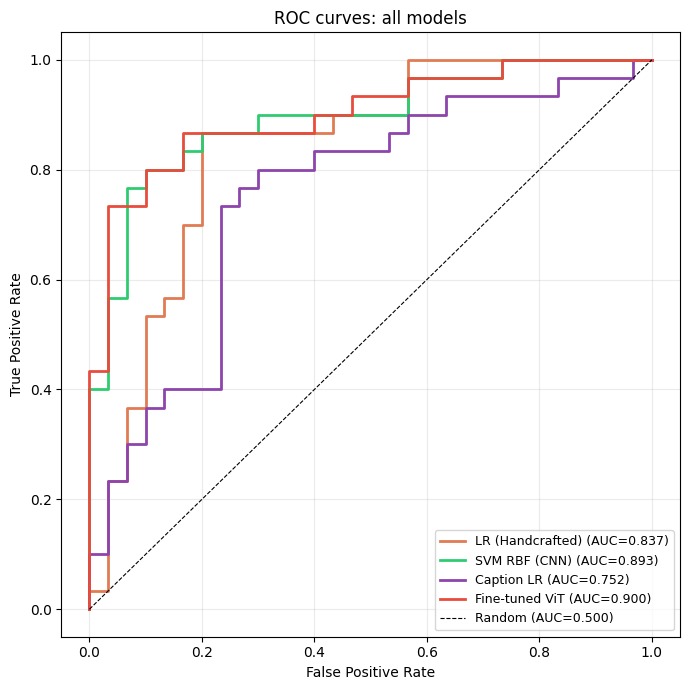

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
color_map = {
    'LR (Handcrafted)': '#E07B54',
    'SVM RBF (CNN)': '#2ECC71',
    'Caption LR': '#8E44AD',
    'Fine-tuned ViT': '#E74C3C',
}
for name, r in all_results.items():
    ax.plot(r['fpr'], r['tpr'], color=color_map.get(name, 'gray'),
            lw=2, label=f'{name} (AUC={r["auc"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves: all models')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('fig_roc_all.png', dpi=150, bbox_inches='tight')
plt.show()

### A-21: Confusion Matrices

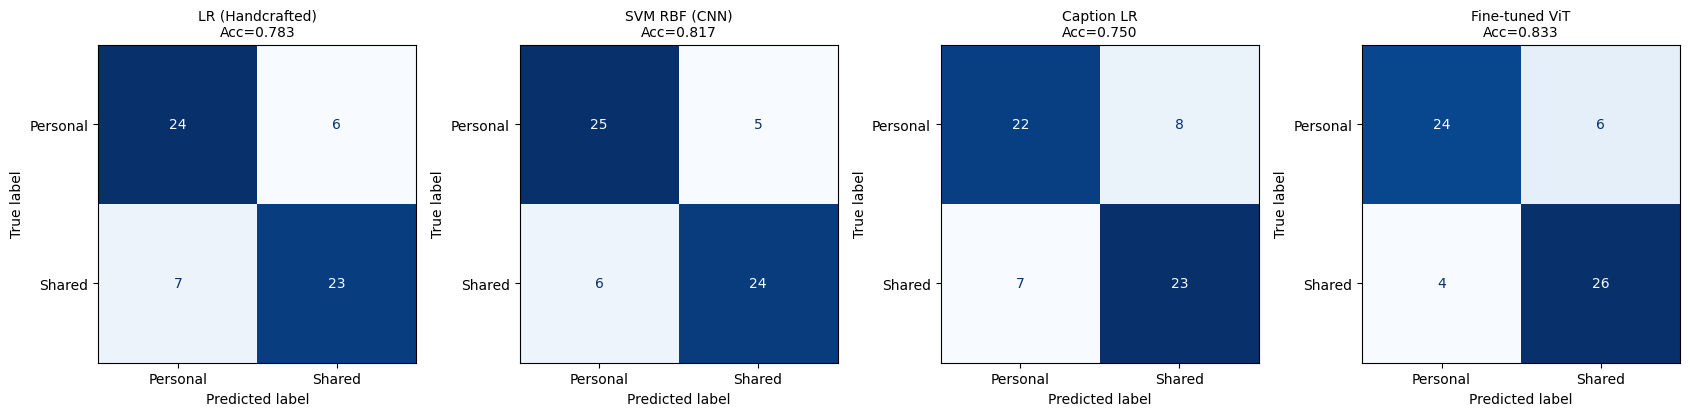


FP/FN breakdown:
  LR (Handcrafted)      TN=24  FP= 6  FN= 7  TP=23
  SVM RBF (CNN)         TN=25  FP= 5  FN= 6  TP=24
  Caption LR            TN=22  FP= 8  FN= 7  TP=23
  Fine-tuned ViT        TN=24  FP= 6  FN= 4  TP=26


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, (name, r) in zip(axes, all_results.items()):
    cm = confusion_matrix(y_test, r['preds'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Personal', 'Shared'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc={r["accuracy"]:.3f}', fontsize=10)
plt.tight_layout()
plt.savefig('fig_cm_all.png', dpi=150, bbox_inches='tight')
plt.show()

# Print FP/FN breakdown
print('\nFP/FN breakdown:')
for name, r in all_results.items():
    cm = confusion_matrix(y_test, r['preds'])
    tn, fp, fn, tp = cm.ravel()
    print(f'  {name:20s}  TN={tn:2d}  FP={fp:2d}  FN={fn:2d}  TP={tp:2d}')

## Section 8: Analysis & Interpretation

### A-22: Caption Word Frequency & Examples

In [ ]:
# ── Caption examples: 3 correct shared, 3 correct personal, 1 FP, 1 FN ─────
cap_preds = res_cap['preds']
cap_probs = res_cap['probs']
test_caps = [captions[i] for i in idx_test]

correct_shared = [i for i in range(len(y_test))
                  if cap_preds[i] == 1 and y_test[i] == 1]
correct_personal = [i for i in range(len(y_test))
                    if cap_preds[i] == 0 and y_test[i] == 0]
false_pos = [i for i in range(len(y_test))
             if cap_preds[i] == 1 and y_test[i] == 0]
false_neg = [i for i in range(len(y_test))
             if cap_preds[i] == 0 and y_test[i] == 1]

selected = (correct_shared[:3] + correct_personal[:3] +
            false_pos[:1] + false_neg[:1])

case_rows = []
for local_idx in selected:
    case_rows.append({
        'filename': os.path.basename(test_paths[local_idx]),
        'caption': test_caps[local_idx],
        'true': 'Shared' if y_test[local_idx] == 1 else 'Personal',
        'pred': 'Shared' if cap_preds[local_idx] == 1 else 'Personal',
        'P(Shared)': round(float(cap_probs[local_idx]), 3),
        'correct': '✓' if cap_preds[local_idx] == y_test[local_idx] else '✗',
    })
case_df = pd.DataFrame(case_rows)
print('Caption examples:')
print(case_df.to_string(index=False))

Caption examples:
                                          filename                                            caption     true     pred  P(Shared) correct
EF93DEA1-AF52-4031-9E79-B187B0CEE122_4_5005_c.jpeg            an open doorway with a view of the city   Shared   Shared      0.549       ✓
391375F7-BCD2-4BBE-BBD3-BB25253B5B74_4_5005_c.jpeg         a couple of birds sitting on top of a boat   Shared   Shared      0.529       ✓
7DEE5775-7619-4EE2-9AB3-481AFDE8A834_4_5005_c.jpeg        a person standing in the middle of a desert   Shared   Shared      0.674       ✓
 8DC2083D-1D42-4AA7-8744-D6950F1FD887_1_105_c.jpeg               a man and woman standing in the snow Personal Personal      0.493       ✓
28ABE5FA-9264-4141-9A0E-C0D78FFAD677_4_5005_c.jpeg  two women sitting on a bench in front of a window Personal Personal      0.483       ✓
 47D81B18-9F4B-494C-8B59-DF1830AA9EE4_1_105_c.jpeg          two women sitting at a table eating pizza Personal Personal      0.370       ✓
 27163ED0

In [ ]:
# ── Top-5 and bottom-5 P(Shared) from training set ────────────────────────────
train_cap_probs = best_cap_lr.predict_proba(X_cap_train_s)[:, 1]
train_caps = [captions[i] for i in idx_train]

order = np.argsort(train_cap_probs)
bottom_5 = order[:5]
top_5 = order[-5:][::-1]

print('TOP 5 P(Shared) captions (training set):')
for i in top_5:
    print(f'  {train_cap_probs[i]:.3f}  [true: {"Shared" if y_train[i]==1 else "Personal"}]  "{train_caps[i]}"')

print('\nBOTTOM 5 P(Shared) captions (training set):')
for i in bottom_5:
    print(f'  {train_cap_probs[i]:.3f}  [true: {"Shared" if y_train[i]==1 else "Personal"}]  "{train_caps[i]}"')

TOP 5 P(Shared) captions (training set):
  0.807  [true: Shared]  "a sandy beach with trees and bushes in the fore"
  0.804  [true: Shared]  "stairs leading to the beach"
  0.796  [true: Shared]  "a beach with rocks and trees on the shore"
  0.788  [true: Shared]  "a river with trees and mountains in the background"
  0.773  [true: Shared]  "a view of the ocean from the top of a hill"

BOTTOM 5 P(Shared) captions (training set):
  0.253  [true: Personal]  "a screen shot of a computer with the text ' snit ' on it"
  0.266  [true: Personal]  "two women sitting at a table with laptops"
  0.269  [true: Shared]  "a man preparing food in a restaurant kitchen"
  0.276  [true: Personal]  "a woman holding a bowl of food in a kitchen"
  0.281  [true: Personal]  "a group of people taking a selfie self self"


### A-23: Attention Rollout (Abnar & Zuidema, 2020)

Account for residual connections by defining $\hat{A}^{\ell} = 0.5 \bar{A}^{\ell} + 0.5 I$, then take the product across layers:

$$\mathbf{R} = \hat{A}^1 \cdot \hat{A}^2 \cdots \hat{A}^L$$

The first row $\mathbf{R}[0, 1:]$ gives the total attention each spatial patch receives from the [CLS] token after propagation through all 12 layers.

In [ ]:
def compute_attention_rollout(model, img_tensor, device):
    """Compute attention rollout map for a single ViT input.

    Implementation:
    1. Forward with output_attentions=True to get per-layer attention tensors
       of shape (batch=1, n_heads, N+1, N+1).
    2. Average across heads -> (L, N+1, N+1).
    3. Add residual: A_hat = 0.5 * A_mean + 0.5 * I.
    4. Multiply matrices across layers.
    5. Take R[0, 1:] (CLS row, skip CLS self-entry), reshape to 14x14.

    Returns:
        spatial (np.ndarray): (14, 14) normalised heatmap in [0, 1]
        predicted_class (int)
    """
    model.eval()
    img_tensor = img_tensor.to(device)
    with torch.no_grad():
        outputs = model(pixel_values=img_tensor.unsqueeze(0),
                        output_attentions=True)
    # outputs.attentions is a tuple of length L, each (1, n_heads, N+1, N+1)
    if outputs.attentions is None:
        raise ValueError("Attentions not returned. Make sure model.config.output_attentions = True")

    attentions = [a[0] for a in outputs.attentions]

    # Mean across heads at each layer
    avg_attentions = [a.mean(dim=0) for a in attentions]  # list of (N+1, N+1)

    n_tokens = avg_attentions[0].shape[0]
    eye = torch.eye(n_tokens, device=device)

    # Start with identity and multiply in layer order
    rollout = torch.eye(n_tokens, device=device)
    for A_mean in avg_attentions:
        A_hat = 0.5 * A_mean + 0.5 * eye
        # Row-normalise so each row sums to 1
        A_hat = A_hat / A_hat.sum(dim=-1, keepdim=True)
        rollout = A_hat @ rollout

    # First row: attention flowing from CLS to all tokens
    cls_attn = rollout[0, 1:]  # skip CLS self-entry → length N=196
    grid = int(np.sqrt(cls_attn.shape[0]))  # 14
    spatial = cls_attn.reshape(grid, grid).cpu().numpy()

    # Normalise to [0, 1]
    spatial = spatial - spatial.min()
    if spatial.max() > 0:
        spatial = spatial / spatial.max()

    pred_class = int(outputs.logits.argmax(dim=1).item())
    return spatial, pred_class

# Quick sanity check on one test image
sample_img = PILImage.open(test_paths[0]).convert('RGB')
sample_tensor = vit_eval_transform(sample_img)
sample_map, sample_pred = compute_attention_rollout(vit_model, sample_tensor, DEVICE)
print(f'Attention rollout shape: {sample_map.shape}, pred class: {sample_pred}')

Attention rollout shape: (14, 14), pred class: 0


### A-24: Attention Map Visualisations

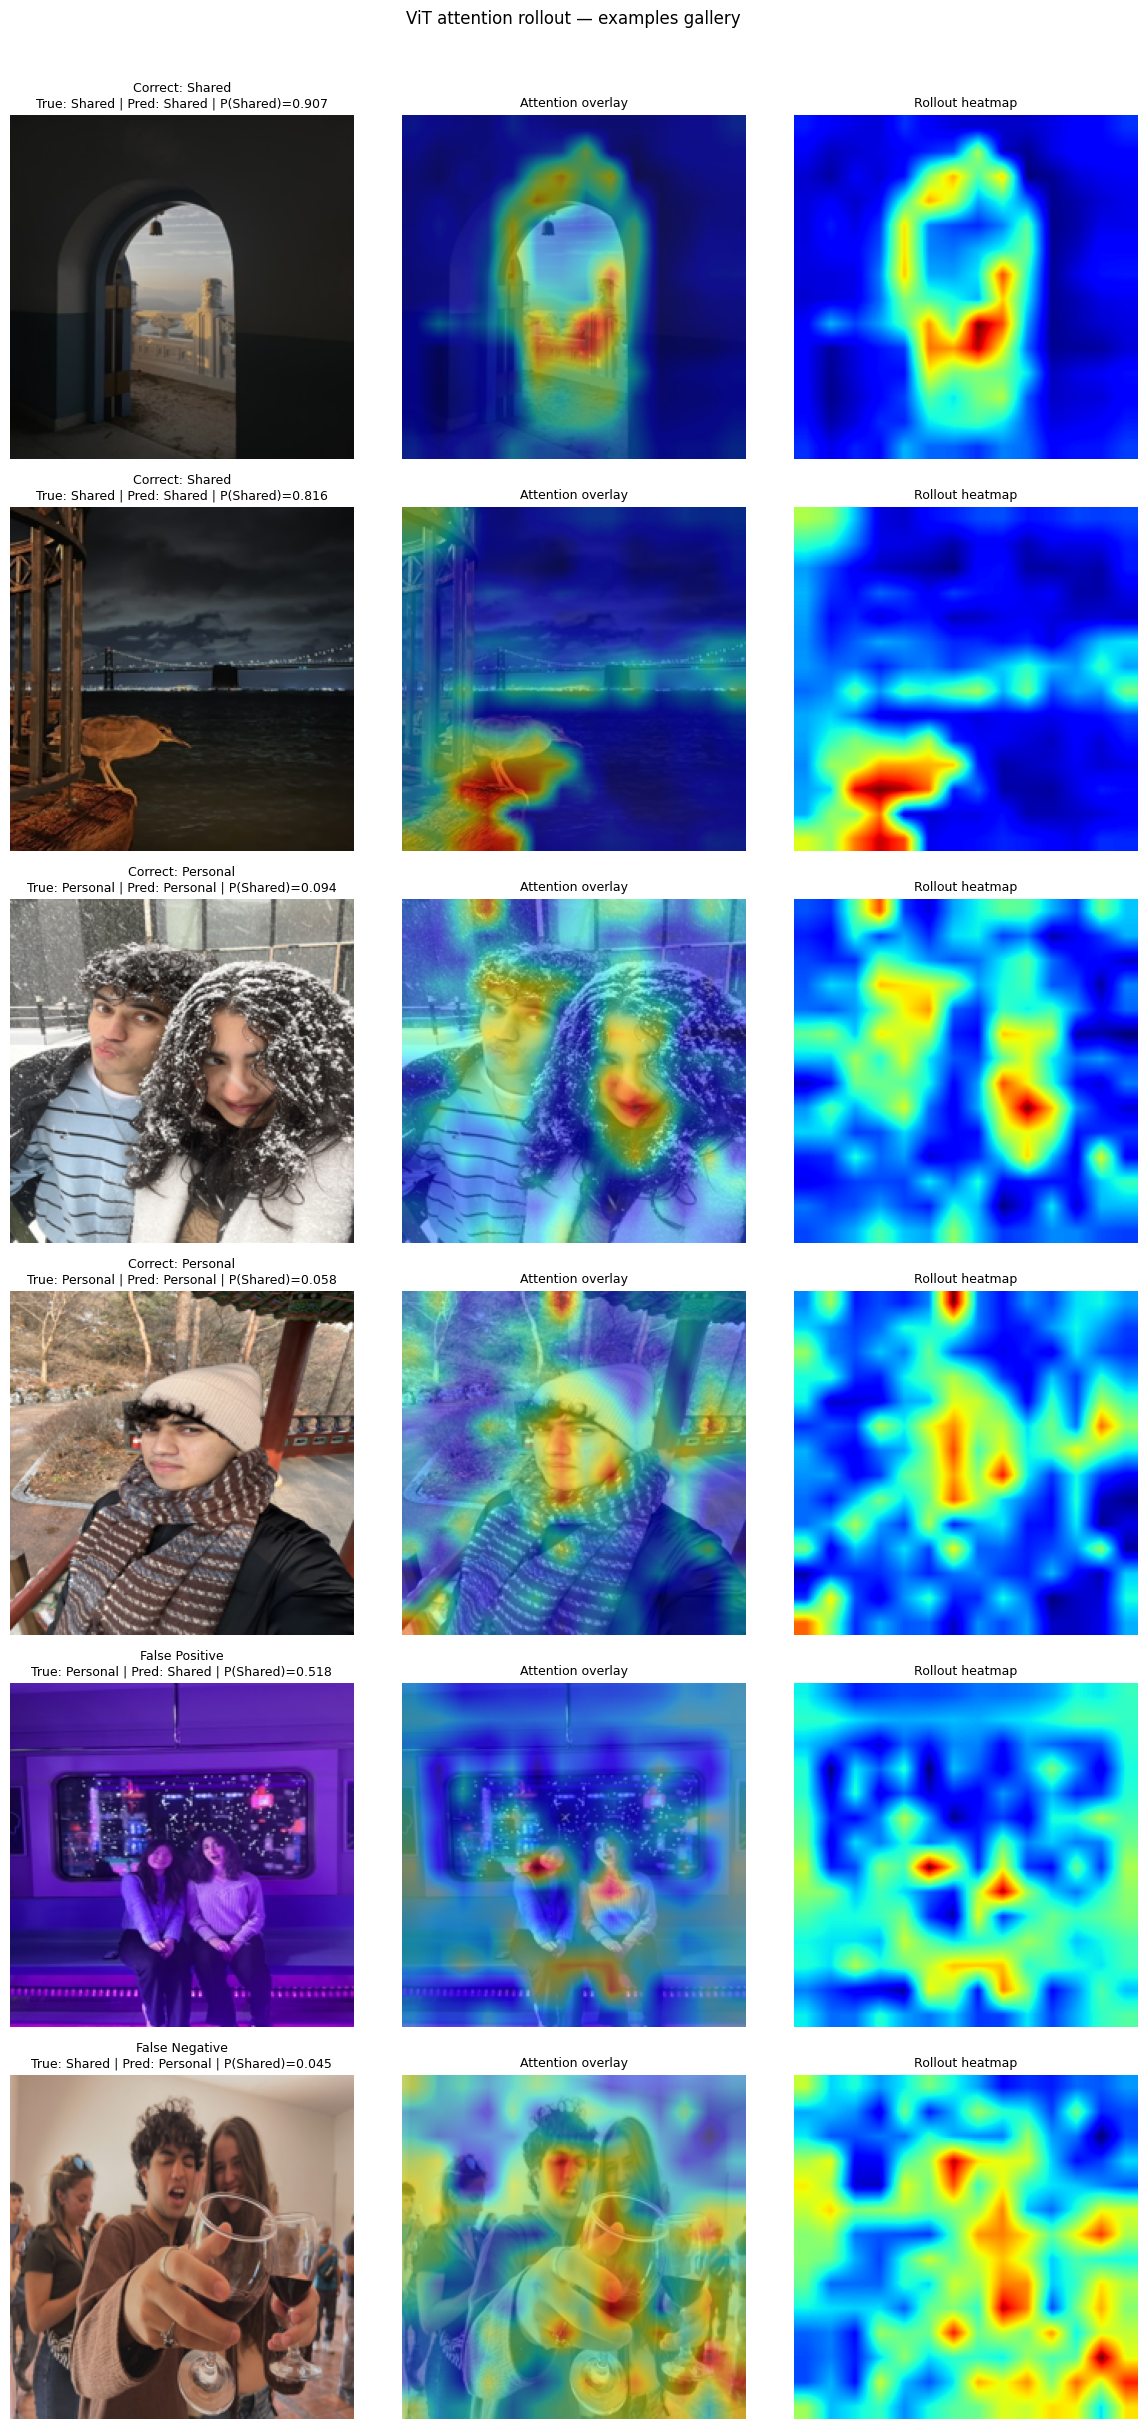

In [ ]:
# Pick: 2 correct shared, 2 correct personal, 1 FP, 1 FN (for the ViT)
vit_preds = res_vit['preds']
v_correct_shared = [i for i in range(len(y_test))
                    if vit_preds[i] == 1 and y_test[i] == 1][:2]
v_correct_personal = [i for i in range(len(y_test))
                      if vit_preds[i] == 0 and y_test[i] == 0][:2]
v_false_pos = [i for i in range(len(y_test))
               if vit_preds[i] == 1 and y_test[i] == 0][:1]
v_false_neg = [i for i in range(len(y_test))
               if vit_preds[i] == 0 and y_test[i] == 1][:1]

gallery = v_correct_shared + v_correct_personal + v_false_pos + v_false_neg
labels_gallery = (['Correct: Shared'] * len(v_correct_shared) +
                  ['Correct: Personal'] * len(v_correct_personal) +
                  ['False Positive'] * len(v_false_pos) +
                  ['False Negative'] * len(v_false_neg))

n_examples = len(gallery)
fig, axes = plt.subplots(n_examples, 3, figsize=(12, 4 * n_examples))
if n_examples == 1:
    axes = axes[np.newaxis, :]

for row, (local_idx, case_name) in enumerate(zip(gallery, labels_gallery)):
    img = PILImage.open(test_paths[local_idx]).convert('RGB').resize((224, 224))
    img_tensor = vit_eval_transform(PILImage.open(test_paths[local_idx]).convert('RGB'))
    heatmap_14, _ = compute_attention_rollout(vit_model, img_tensor, DEVICE)
    heatmap_224 = cv2.resize(heatmap_14, (224, 224))

    true_str = 'Shared' if y_test[local_idx] == 1 else 'Personal'
    pred_str = 'Shared' if vit_preds[local_idx] == 1 else 'Personal'
    prob = res_vit['probs'][local_idx]

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(
        f'{case_name}\nTrue: {true_str} | Pred: {pred_str} | P(Shared)={prob:.3f}',
        fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(img)
    axes[row, 1].imshow(heatmap_224, cmap='jet', alpha=0.5)
    axes[row, 1].set_title('Attention overlay', fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(heatmap_224, cmap='jet')
    axes[row, 2].set_title('Rollout heatmap', fontsize=9)
    axes[row, 2].axis('off')

plt.suptitle('ViT attention rollout — examples gallery', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_attention_gallery.png', dpi=150, bbox_inches='tight')
plt.show()

### A-25: Data Cut Analysis

In [ ]:
# Reconstruct the test-set handcrafted DataFrame
df_test = df.iloc[idx_test].reset_index(drop=True)
brightness_median = df_test['mean_brightness'].median()

cuts = {
    'Bright photos': df_test['mean_brightness'] >= brightness_median,
    'Dark photos': df_test['mean_brightness'] < brightness_median,
    'Face present': df_test['face_present'] == 1,
    'No face': df_test['face_present'] == 0,
}

cut_rows = []
for cut_name, mask in cuts.items():
    m = mask.values
    n = int(m.sum())
    if n < 3:
        continue
    for name, r in all_results.items():
        acc = accuracy_score(y_test[m], r['preds'][m])
        cut_rows.append({
            'Data Cut': f'{cut_name} (n={n})',
            'Model': name,
            'Accuracy': round(acc, 3),
        })

cut_df = pd.DataFrame(cut_rows)
cut_pivot = cut_df.pivot_table(index='Model', columns='Data Cut',
                               values='Accuracy', aggfunc='first')
print('Data cut table:')
print(cut_pivot.round(3).to_string())

Data cut table:
Data Cut          Bright photos (n=30)  Dark photos (n=30)  Face present (n=8)  No face (n=52)
Model                                                                                         
Caption LR                       0.700               0.800               0.875           0.731
Fine-tuned ViT                   0.767               0.900               0.750           0.846
LR (Handcrafted)                 0.800               0.767               1.000           0.750
SVM RBF (CNN)                    0.833               0.800               0.750           0.827


### A-26: All-Models-Wrong Cases

Images where >=3/4 models wrong: 6
Images where ALL 4 models wrong: 1


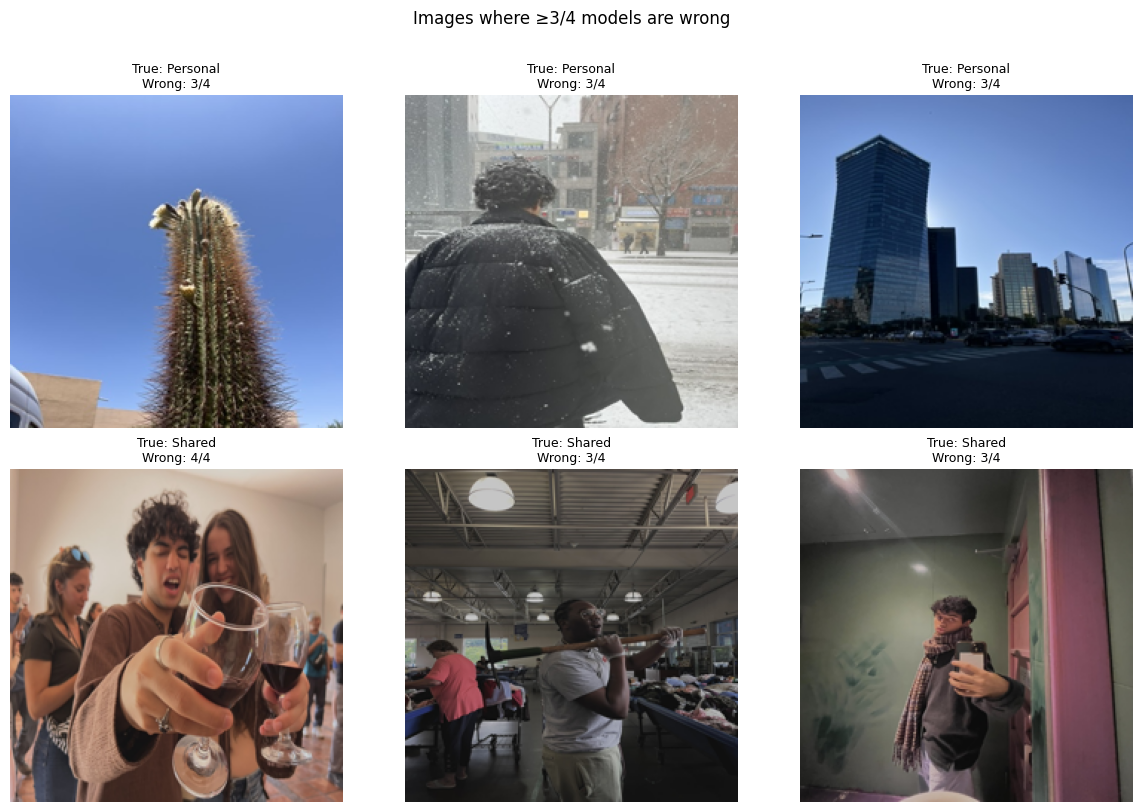


Per-model predictions for these cases:
                                          filename     true                                                 caption hand svm cap vit  wrong
91736232-DB9F-480B-85EC-736D2CC039DD_4_5005_c.jpeg Personal                   a large cactus in front of a building    S   S   S   P      3
DCF8E411-3B6F-49A9-AEB2-D2C4402FE3B1_4_5005_c.jpeg Personal            a person walking down the street in the snow    P   S   S   S      3
006CD23E-A7AE-4F13-9AD1-B420322E26BA_4_5005_c.jpeg Personal a city street with cars and buildings in the background    P   S   S   S      3
 BAD118B3-0F0A-494B-9F1E-A96BAD783449_1_105_c.jpeg   Shared      two people are holding wine glasses in their hands    P   P   P   P      4
 C2DB1FD0-154D-4875-8034-DD1D4E01CF22_1_105_c.jpeg   Shared                  a man holding a baseball bat in a room    S   P   P   P      3
 87495135-92B4-4442-9CB3-42DB18CB6D95_1_105_c.jpeg   Shared                   a person taking a picture in a mirror    S

In [ ]:
# For each test image, count how many of the 4 models got it wrong
wrong_counts = np.zeros(len(y_test), dtype=int)
for name, r in all_results.items():
    wrong_counts += (r['preds'] != y_test).astype(int)

mostly_wrong_idx = np.where(wrong_counts >= 3)[0]
print(f'Images where >=3/4 models wrong: {len(mostly_wrong_idx)}')

all_wrong_idx = np.where(wrong_counts == 4)[0]
print(f'Images where ALL 4 models wrong: {len(all_wrong_idx)}')

# Show up to 6 of the mostly-wrong cases
show_idx = mostly_wrong_idx[:6] if len(mostly_wrong_idx) > 0 else []

if len(show_idx) > 0:
    n_show = len(show_idx)
    ncols = min(3, n_show)
    nrows = int(np.ceil(n_show / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1 or ncols == 1:
        axes = axes.reshape(nrows, ncols)

    rows_info = []
    for k, local_idx in enumerate(show_idx):
        r, c = k // ncols, k % ncols
        img = PILImage.open(test_paths[local_idx]).convert('RGB').resize((224, 224))
        axes[r, c].imshow(img)
        axes[r, c].axis('off')
        true_str = 'Shared' if y_test[local_idx] == 1 else 'Personal'
        axes[r, c].set_title(f'True: {true_str}\nWrong: {wrong_counts[local_idx]}/4',
                             fontsize=9)

        rows_info.append({
            'filename': os.path.basename(test_paths[local_idx]),
            'true': true_str,
            'caption': captions[idx_test[local_idx]],
            'hand': 'S' if res_hand['preds'][local_idx] == 1 else 'P',
            'svm': 'S' if res_svm['preds'][local_idx] == 1 else 'P',
            'cap': 'S' if res_cap['preds'][local_idx] == 1 else 'P',
            'vit': 'S' if res_vit['preds'][local_idx] == 1 else 'P',
            'wrong': int(wrong_counts[local_idx]),
        })

    # Hide any unused panels
    for k in range(n_show, nrows * ncols):
        r, c = k // ncols, k % ncols
        axes[r, c].axis('off')

    plt.suptitle('Images where ≥3/4 models are wrong', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('fig_all_wrong.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nPer-model predictions for these cases:')
    print(pd.DataFrame(rows_info).to_string(index=False))
else:
    print('No images with ≥3 model errors.')

## Section 9: Executive Summary

Key results assembled into one place.

In [ ]:
print('=' * 70)
print('SUMMARY — ITERATION III')
print('=' * 70)
print(f'LR (Handcrafted):  CV={cv_lr_hand.mean():.3f}±{cv_lr_hand.std():.3f}, Test={res_hand["accuracy"]:.3f}, AUC={res_hand["auc"]:.3f}')
print(f'SVM RBF (CNN):     CV={svm_search.best_score_:.3f}, Test={res_svm["accuracy"]:.3f}, AUC={res_svm["auc"]:.3f}')
print(f'Caption LR:        CV={best_cv_cap:.3f}, Test={res_cap["accuracy"]:.3f}, AUC={res_cap["auc"]:.3f}')
print(f'Fine-tuned ViT:    Best val={max(vit_history["val_acc"]):.3f} (epoch {vit_best_epoch}), Test={res_vit["accuracy"]:.3f}, AUC={res_vit["auc"]:.3f}')
print()
print(f'Caption LR best C: {best_C_cap}')
print(f'SVM best C, gamma: {svm_search.best_params_["C"]}, {svm_search.best_params_["gamma"]}')

SUMMARY — ITERATION III
LR (Handcrafted):  CV=0.775±0.031, Test=0.783, AUC=0.837
SVM RBF (CNN):     CV=0.817, Test=0.817, AUC=0.893
Caption LR:        CV=0.775, Test=0.750, AUC=0.752
Fine-tuned ViT:    Best val=0.854 (epoch 14), Test=0.833, AUC=0.900

Caption LR best C: 0.001
SVM best C, gamma: 10.0, scale


## Section 10: References

New for Iteration III:

- Abnar, S. & Zuidema, W. (2020). Quantifying Attention Flow in Transformers. ACL 2020.
- Dosovitskiy, A. et al. (2021). An Image is Worth 16x16 Words. ICLR 2021.
- Li, J. et al. (2022). BLIP: Bootstrapping Language-Image Pre-training. ICML 2022.
- Loshchilov, I. & Hutter, F. (2019). Decoupled Weight Decay Regularization. ICLR 2019.
- Reimers, N. & Gurevych, I. (2019). Sentence-BERT. EMNLP 2019.
- Wolf, T. et al. (2020). HuggingFace Transformers. EMNLP 2020.

Carried forward from Iterations I and II: Viola & Jones (2001); Hasler & Susstrunk (2003);
He et al. (2016); Radford et al. (2021); Selvaraju et al. (2017); Pedregosa et al. (2011).

## AI Statement

I used ChatGPT and Claude throughout this project as learning tools to deepen my understanding of the
concepts involved, particularly BLIP's cross-attention mechanism, attention rollout
(Abnar & Zuidema, 2020), and the AdamW update rule. Where I encountered topics I had seen introduced but
not fully developed, I used these tools to find additional resources, alternative explanations, and
relevant papers that helped me build a stronger conceptual foundation. I also used them to check code
structure and help organise writing. The code, analysis, and conclusions in this notebook are my own.